In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
from os import environ


# IN_COLAB = False
# if "DRIVE_HOME" in environ:
  # ROOT = Path(f"{environ.get("DRIVE_HOME")}/colab/outputs/waterloo-slt-reading-group")
# else:
ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixture/binom2d")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/wbic-bias")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data
Using outputdir=/mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/wbic-bias


In [3]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,p0,p1,w0,w1
0,regular,0.15,0.35,0.75,0.25
1,e-singular,0.25,0.35,0.75,0.25
2,singular1,0.15,0.35,1.00,0.00
3,singular2,0.35,0.35,0.75,0.25


In [4]:
from sklearn_extensions.mixbinom import BinomialMixture


def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
  return truth

def rlct_by_dsid(dsid: str):
  truth = find_truth_by_dsid(dsid)
  n_components = np.ceil(len(truth)/2)
  rlct = None
  match dsid:
    case "regular" | "e-singular":
      rlct = (n_components*2-1)/2
    case "singular1" | "singular2":
      rlct = 1
    case _:
      raise Exception(f"Uknown dsid={dsid}")

  return rlct

def approx_free_energy_by_dsid(dsid, n_trials, X):
  n=len(X)
  
  average_log_likelihood = None
  model = BinomialMixture(n_components=2, n_trials=n_trials, enforce_ordering=False)
  input_data = np.column_stack([X, np.full_like(X, n_trials)])
  model.fit(input_data)
  mle, _ = model.point_estimate()
  log_p = mixbinom.logpmf(weights=[mle[2], 1-mle[2]], probs=[mle[0], mle[1]], n=n_trials, x=X) # sample likelihood under the mle
  average_log_likelihood = log_p.mean()

  afe = -n_obs*average_log_likelihood+rlct_by_dsid(dsid)*np.log(n_obs)
  return afe


def expected_free_energy_by_dsid(dsid, n_trials, n):
  X = np.arange(0, n_trials, 1)
  truth = find_truth_by_dsid(dsid)
  weights_0=truth[2:3]
  probs_0=truth[0:1]

  log_q = mixbinom.logpmf(n=n_trials, weights=weights_0, probs=probs_0, x=X)
  log_p = mixbinom.logpmf(n=n_trials, weights=weights_0, probs=probs_0, x=X)
  expected_log_likelihood = np.exp(log_q)*log_p
  second_order_term = rlct_by_dsid(dsid)*np.log(n)

  efe = -n * expected_log_likelihood.sum() + second_order_term
  return efe

In [5]:
# compute AFE and WBIC for many samples, 
# AFE requires sampling with beta=1 while WBIC requires sampling with beta=1/sqrt(n)
# for different n

In [6]:
import pandas as pd
import json
from pathlib import Path

results_file = Path(f"{outputdir}/fe_estimators_results.csv")

# Load existing results if file exists
if results_file.exists():
  fe_estimators_df = pd.read_csv(results_file)
  # Create a set of completed (run, regime, dsid) tuples for fast lookup
  completed = set(
      zip(fe_estimators_df["trial"], fe_estimators_df["regime"], fe_estimators_df["dsid"])
  )
  fe_estimators_data = fe_estimators_df.to_dict("records")
else:
  completed = set()
  fe_estimators_data = []

def save_results():
  """Save current results to disk."""
  pd.DataFrame(fe_estimators_data).to_csv(results_file, index=False)

In [ ]:
from pymc_extensions.tempered_mixbinom import TemperedBinomialMixture
from pymc_extensions import pmx
from scipy_extensions import mixbinom
from tqdm.notebook import tqdm
import pymc as pm
import numpy as np
import arviz as az


n_components = 2
n_trials=100
regimes = [50, 250, 5000]

# mcmc settings
n_tune=4000
n_draws=1000
n_chains=4

# read all the data so we can nicely loop 
for run in tqdm(range(1000), desc=f"runs "):
  for regime in tqdm(regimes, desc="regimes"):
    for dsid in dgps["dsid"].unique():
      # Skip if already completed
      if (run, regime, dsid) in completed:
          continue

      # try:
      dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")

      X = dataset.iloc[:, run].to_numpy()
      n_obs = len(X)
      efe = expected_free_energy_by_dsid(dsid=dsid, n_trials=n_trials, n=n_obs)
      afe = approx_free_energy_by_dsid(dsid=dsid, n_trials=n_trials, X=X)

      with TemperedBinomialMixture(X=X, n_trials=100, beta=1/np.log(n_obs)) as model:
        idata = model.sample(draws=n_draws, 
                             tune=n_tune, 
                             chains=n_chains, 
                             progressbar=False)  # or "blackjax"

        # Divergences are stored in sample_stats as a boolean array (chain, draw)
        diverging = idata.sample_stats.diverging.values
        
        # Divergences per chain
        divs_per_chain = diverging.sum(axis=1)  # array with one value per chain
        
        # Summary statistics
        mean_divergences = divs_per_chain.mean()
        total_divergences = diverging.sum()
        max_divergences = divs_per_chain.max()
        
        weights = pmx.column_stack_vars(idata, ["weights"])
        probs = pmx.column_stack_vars(idata, ["p0", "p1"])
        log_likelihood = mixbinom.log_likelihood(weights, probs, n=n_trials, x=X)
        wbic = -log_likelihood.mean()
        print(f"run={run}, regime={regime}, dsid={dsid},wbic={wbic}, afe={afe}, efe={efe}")
        result = {
          "dsid": dsid,
          "regime": regime,
          "n": regime,
          "trial": run,
          "wbic": wbic,
          "afe": afe,
          "efe": efe,
          "chains": n_chains,
          "draws": n_draws,
          "tune": n_tune,
          "mean_divergences": mean_divergences,
          "total_divergences": total_divergences,
          "max_divergences": max_divergences,
          "divergences_per_chain": divs_per_chain.tolist(),
          "chain_tree_depth": idata.sample_stats.tree_depth.values.max()
        }

        fe_estimators_data.append(result)
        completed.add((run, regime, dsid))
        
  # Save after each successful run
  save_results()
  !git add "../../outputs/mixture/binom2d/wbic-bias/fe_estimators_results.csv"
  !git commit -m "more runs"
  !git push

runs :   0%|          | 0/1000 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

[feature/mixpoisson2d 9aaf5a9] more runs
 Committer: Ashraf Ahmed (a383ahme) <a383ahme@jupyter-p03.math.uwaterloo.ca>
Your name and email address were configured automatically based
on your username and hostname. Please check that they are accurate.
You can suppress this message by setting them explicitly. Run the
following command and follow the instructions in your editor to edit
your configuration file:

    git config --global --edit

After doing this, you may fix the identity used for this commit with:

    git commit --amend --reset-author

 1 file changed, 10 insertions(+), 10 deletions(-)
Enumerating objects: 21, done.
Counting objects: 100% (21/21), done.
Delta compression using up to 128 threads
Compressing objects: 100% (11/11), done.
Writing objects: 100% (11/11), 974 bytes | 974.00 KiB/s, done.
Total 11 (delta 6), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (6/6), completed with 6 local objects.
To github.com:RealAshrafAhmed/waterloo-slt-reading-group.

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

On branch feature/mixpoisson2d
Your branch is up to date with 'origin/feature/mixpoisson2d'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   binom2d-wbic-bias.ipynb
	modified:   ../poisson3d/poisson3d-wbic-bias.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
Everything up-to-date


...

wbic=15986.65605882653, afe=15986.863978733205, efe=11904.275348565288


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

In [ ]:
fe_estimates_df = pd.DataFrame(fe_estimators_data)
fe_estimates_df.style.format({'wbic': '{:.3f}', 'efe': '{:.3f}'})
fe_estimates_df.head()

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Compute the differences
fe_estimates_df['wbic_minus_afe'] = fe_estimates_df['wbic'] - fe_estimates_df['afe']
fe_estimates_df['wbic_minus_efe'] = fe_estimates_df['wbic'] - fe_estimates_df['efe']

# Summary statistics
summary = fe_estimates_df.groupby(['dsid', 'n']).agg(
    wbic_afe_mean=('wbic_minus_afe', 'mean'),
    wbic_afe_std=('wbic_minus_afe', 'std'),
    wbic_efe_mean=('wbic_minus_efe', 'mean'),
    wbic_efe_std=('wbic_minus_efe', 'std'),
).reset_index()

# Get RLCT for each dsid
dsids = fe_estimates_df['dsid'].unique()
n_range = np.linspace(fe_estimates_df['n'].min(), fe_estimates_df['n'].max(), 100)

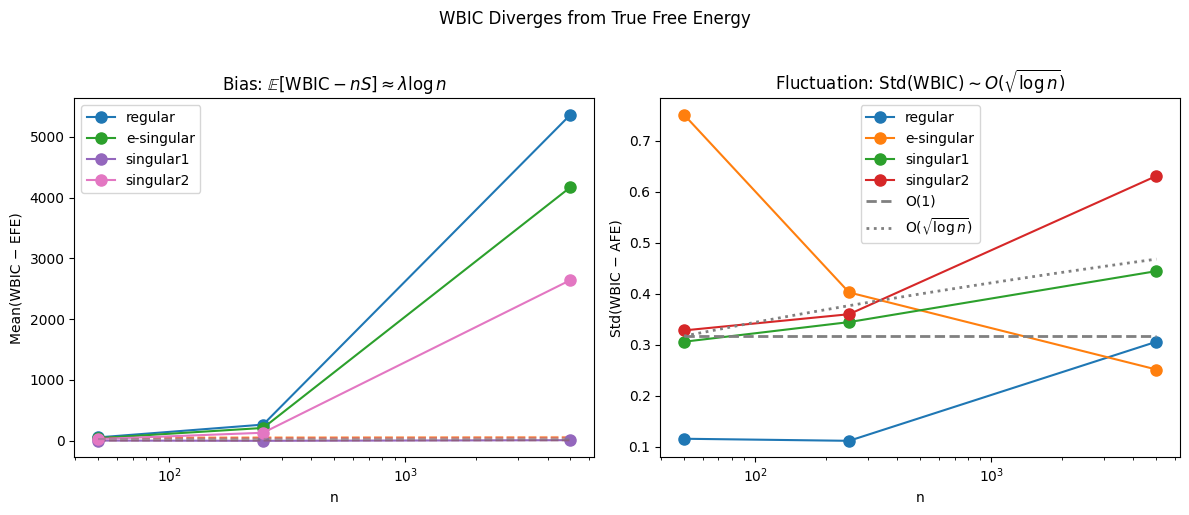

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Bias (Mean of WBIC - EFE) ~ λ log(n)
ax = axes[0]
for dsid in dsids:
    data = summary[summary['dsid'] == dsid]
    ax.plot(data['n'], data['wbic_efe_mean'], 'o-', label=dsid, markersize=8)
    
    # Theoretical reference: λ log(n) anchored at first point
    lam = rlct_by_dsid(dsid)
    n0 = data['n'].iloc[0]
    offset = data['wbic_efe_mean'].iloc[0] - lam * np.log(n0)
    ax.plot(n_range, lam * np.log(n_range) + offset, '--', alpha=0.5)

ax.set_xscale('log')
ax.set_xlabel('n')
ax.set_ylabel('Mean(WBIC − EFE)')
ax.set_title(r'Bias: $\mathbb{E}[\mathrm{WBIC} - nS] \approx \lambda \log n$')
ax.legend()

# Right: Fluctuation (Std of WBIC - AFE) ~ √log(n)
ax = axes[1]
for dsid in dsids:
    data = summary[summary['dsid'] == dsid]
    ax.plot(data['n'], data['wbic_afe_std'], 'o-', label=dsid, markersize=8)

# Reference lines
n0 = summary['n'].min()
std0 = summary[summary['n'] == n0]['wbic_afe_std'].median()

ax.plot(n_range, np.full_like(n_range, std0), '--', color='gray', linewidth=2, label='O(1)')
c = std0 / np.sqrt(np.log(n0))
ax.plot(n_range, c * np.sqrt(np.log(n_range)), ':', color='gray', linewidth=2, label=r'O($\sqrt{\log n}$)')

ax.set_xscale('log')
ax.set_xlabel('n')
ax.set_ylabel('Std(WBIC − AFE)')
ax.set_title(r'Fluctuation: $\mathrm{Std}(\mathrm{WBIC}) \sim O(\sqrt{\log n})$')
ax.legend()

plt.suptitle('WBIC Diverges from True Free Energy', y=1.02)
plt.tight_layout()
plt.show()

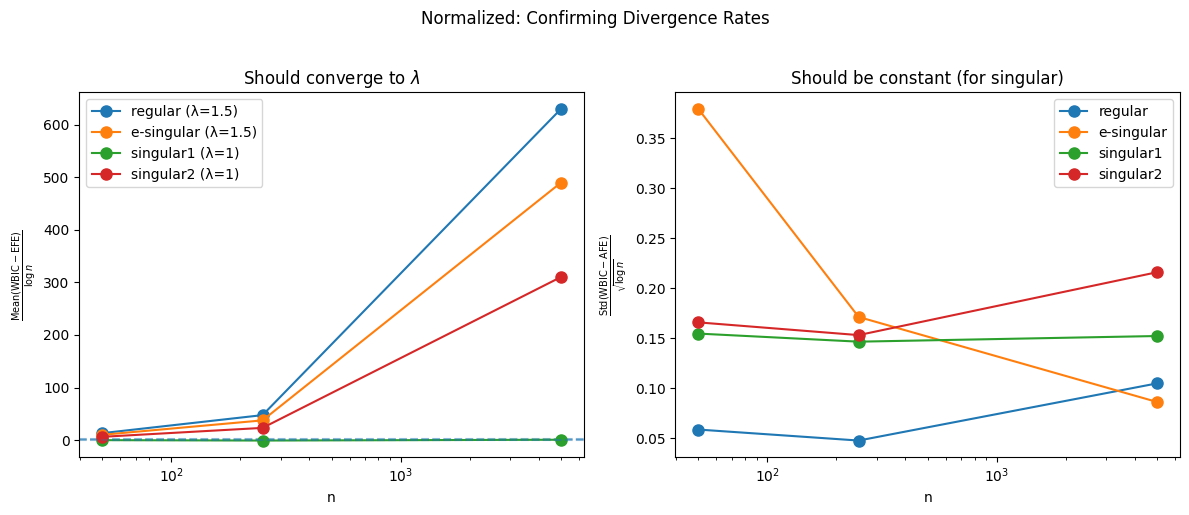

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Bias / log(n) → λ
ax = axes[0]
for dsid in dsids:
    data = summary[summary['dsid'] == dsid]
    normalized = data['wbic_efe_mean'] / np.log(data['n'])
    lam = rlct_by_dsid(dsid)
    ax.plot(data['n'], normalized, 'o-', label=f'{dsid} (λ={lam})', markersize=8)
    ax.axhline(lam, linestyle='--', alpha=0.3)

ax.set_xscale('log')
ax.set_xlabel('n')
ax.set_ylabel(r'$\frac{\mathrm{Mean(WBIC - EFE)}}{\log n}$')
ax.set_title(r'Should converge to $\lambda$')
ax.legend()

# Right: Std / √log(n) → constant
ax = axes[1]
for dsid in dsids:
    data = summary[summary['dsid'] == dsid]
    normalized = data['wbic_afe_std'] / np.sqrt(np.log(data['n']))
    ax.plot(data['n'], normalized, 'o-', label=dsid, markersize=8)

ax.set_xscale('log')
ax.set_xlabel('n')
ax.set_ylabel(r'$\frac{\mathrm{Std(WBIC - AFE)}}{\sqrt{\log n}}$')
ax.set_title('Should be constant (for singular)')
ax.legend()

plt.suptitle('Normalized: Confirming Divergence Rates', y=1.02)
plt.tight_layout()
plt.show()